Customer Call List | Data Cleaning

In [92]:
import pandas as pd  # Import the pandas library and give it the alias 'pd' so you can use 'pd' instead of writing 'pandas' every time

In [2]:
df = pd.read_excel(r"C:\Users\Mads\Desktop\Developer Tools and Projects\Python\Customer Call List.xlsx")  
# Read the Excel file located at the given path into a pandas DataFrame called 'df'. 
# 'pd.read_excel' is a pandas function for loading Excel files. 
# The 'r' before the string makes it a raw string, so backslashes in the file path are treated literally.

df  
# Display the contents of the DataFrame 'df' in the output (usually shows the first few rows in Jupyter Notebook or console).

,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact,Not_Useful_Column
0,1001,Frodo,Baggins,123-545-5421,"123 Shire Lane, Shire",Yes,No,True
1,1002,Abed,Nadir,123/643/9775,93 West Main Street,No,Yes,False
2,1003,Walter,/White,7066950392,298 Drugs Driveway,N,NaN,True
3,1004,Dwight,Schrute,123-543-2345,"980 Paper Avenue, Pennsylvania, 18503",Yes,Y,True
4,1005,Jon,Snow,876|678|3469,123 Dragons Road,Y,No,True
5,1006,Ron,Swanson,304-762-2467,768 City Parkway,Yes,Yes,True
6,1007,Jeff,Winger,NaN,1209 South Street,No,No,False
7,1008,Sherlock,Holmes,876|678|3469,98 Clue Drive,N,No,False
8,1009,Gandalf,NaN,N/a,123 Middle Earth,Yes,NaN,False
9,1010,Peter,Parker,123-545-5421,"25th Main Street, New York",Yes,No,True


In [3]:
df = df.drop_duplicates()  
# Remove duplicate rows from the DataFrame 'df'. 
# The function 'drop_duplicates()' checks for identical rows and deletes them, keeping only the first occurrence. 
# The cleaned DataFrame (without duplicates) is then reassigned back to the variable 'df'.

df  
# Display the updated DataFrame 'df' after duplicates have been removed.


,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact,Not_Useful_Column
0,1001,Frodo,Baggins,123-545-5421,"123 Shire Lane, Shire",Yes,No,True
1,1002,Abed,Nadir,123/643/9775,93 West Main Street,No,Yes,False
2,1003,Walter,/White,7066950392,298 Drugs Driveway,N,NaN,True
3,1004,Dwight,Schrute,123-543-2345,"980 Paper Avenue, Pennsylvania, 18503",Yes,Y,True
4,1005,Jon,Snow,876|678|3469,123 Dragons Road,Y,No,True
5,1006,Ron,Swanson,304-762-2467,768 City Parkway,Yes,Yes,True
6,1007,Jeff,Winger,NaN,1209 South Street,No,No,False
7,1008,Sherlock,Holmes,876|678|3469,98 Clue Drive,N,No,False
8,1009,Gandalf,NaN,N/a,123 Middle Earth,Yes,NaN,False
9,1010,Peter,Parker,123-545-5421,"25th Main Street, New York",Yes,No,True


In [4]:
df = df.drop(columns = "Not_Useful_Column")   # Remove the column named "Not_Useful_Column" from the DataFrame 'df' and reassign the result back to 'df'

df # Display the updated DataFrame 'df' after the column has been removed


,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact
0,1001,Frodo,Baggins,123-545-5421,"123 Shire Lane, Shire",Yes,No
1,1002,Abed,Nadir,123/643/9775,93 West Main Street,No,Yes
2,1003,Walter,/White,7066950392,298 Drugs Driveway,N,NaN
3,1004,Dwight,Schrute,123-543-2345,"980 Paper Avenue, Pennsylvania, 18503",Yes,Y
4,1005,Jon,Snow,876|678|3469,123 Dragons Road,Y,No
5,1006,Ron,Swanson,304-762-2467,768 City Parkway,Yes,Yes
6,1007,Jeff,Winger,NaN,1209 South Street,No,No
7,1008,Sherlock,Holmes,876|678|3469,98 Clue Drive,N,No
8,1009,Gandalf,NaN,N/a,123 Middle Earth,Yes,NaN
9,1010,Peter,Parker,123-545-5421,"25th Main Street, New York",Yes,No


In [5]:
# The 'Last_Name' column contains values like:
                        # /White, 
                        # NaN
                        # ...Potter,
                        # Flenderson_

# Remove unnecessary special characters from last names.
df["Last_Name"] = df["Last_Name"].str.strip("123./")
df

,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact
0,1001,Frodo,Baggins,123-545-5421,"123 Shire Lane, Shire",Yes,No
1,1002,Abed,Nadir,123/643/9775,93 West Main Street,No,Yes
2,1003,Walter,White,7066950392,298 Drugs Driveway,N,NaN
3,1004,Dwight,Schrute,123-543-2345,"980 Paper Avenue, Pennsylvania, 18503",Yes,Y
4,1005,Jon,Snow,876|678|3469,123 Dragons Road,Y,No
5,1006,Ron,Swanson,304-762-2467,768 City Parkway,Yes,Yes
6,1007,Jeff,Winger,NaN,1209 South Street,No,No
7,1008,Sherlock,Holmes,876|678|3469,98 Clue Drive,N,No
8,1009,Gandalf,NaN,N/a,123 Middle Earth,Yes,NaN
9,1010,Peter,Parker,123-545-5421,"25th Main Street, New York",Yes,No


In [30]:
# Clean and format 'Phone_Number' entries into the format XXX-XXX-XXXX.

df["Phone_Number"] = df["Phone_Number"].str.replace(r'[^a-zA-Z0-9]', '', regex=True).astype(str).apply(lambda x: x[:3] + '-' + x[3:6] + '-' + x[6:10])    
# Remove all non-alphanumeric characters from values in the 'Phone_Number' column, convert them to strings, 
# then format each phone number into the pattern 'XXX-XXX-XXXX' using a lambda function.

df["Phone_Number"] = df["Phone_Number"].str.replace(r'nan--|Na--|--', '', regex=True)    
# Clean up invalid phone number strings by removing unwanted patterns like 'nan--', 'Na--', or '--' from the 'Phone_Number' column.

df    
# Display the updated DataFrame 'df' after cleaning and formatting the 'Phone_Number' column


,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact
0,1001,Frodo,Baggins,123-545-5421,"123 Shire Lane, Shire",Yes,No
1,1002,Abed,Nadir,123-643-9775,93 West Main Street,No,Yes
2,1003,Walter,White,,298 Drugs Driveway,N,NaN
3,1004,Dwight,Schrute,123-543-2345,"980 Paper Avenue, Pennsylvania, 18503",Yes,Y
4,1005,Jon,Snow,876-678-3469,123 Dragons Road,Y,No
5,1006,Ron,Swanson,304-762-2467,768 City Parkway,Yes,Yes
6,1007,Jeff,Winger,,1209 South Street,No,No
7,1008,Sherlock,Holmes,876-678-3469,98 Clue Drive,N,No
8,1009,Gandalf,NaN,,123 Middle Earth,Yes,NaN
9,1010,Peter,Parker,123-545-5421,"25th Main Street, New York",Yes,No


In [53]:
df[["Street_Address","State","Zip_Code"]] = df["Address"].str.split(',', n=2, expand=True)    
# Split the values in the 'Address' column into three parts using a comma as the separator. 
# The first part goes into 'Street_Address', the second into 'State', and the third into 'Zip_Code'. 
# 'n=2' ensures the split happens at most twice, creating exactly three new columns. 
# 'expand=True' makes pandas return separate columns instead of a list.

df    
# Display the updated DataFrame 'df' with the new columns 'Street_Address', 'State', and 'Zip_Code'


,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact,Street_Address,State,Zip_Code
0,1001,Frodo,Baggins,123-545-5421,"123 Shire Lane, Shire",Yes,No,123 Shire Lane,Shire,None
1,1002,Abed,Nadir,123-643-9775,93 West Main Street,No,Yes,93 West Main Street,None,None
2,1003,Walter,White,,298 Drugs Driveway,N,NaN,298 Drugs Driveway,None,None
3,1004,Dwight,Schrute,123-543-2345,"980 Paper Avenue, Pennsylvania, 18503",Yes,Y,980 Paper Avenue,Pennsylvania,18503
4,1005,Jon,Snow,876-678-3469,123 Dragons Road,Y,No,123 Dragons Road,None,None
5,1006,Ron,Swanson,304-762-2467,768 City Parkway,Yes,Yes,768 City Parkway,None,None
6,1007,Jeff,Winger,,1209 South Street,No,No,1209 South Street,None,None
7,1008,Sherlock,Holmes,876-678-3469,98 Clue Drive,N,No,98 Clue Drive,None,None
8,1009,Gandalf,NaN,,123 Middle Earth,Yes,NaN,123 Middle Earth,None,None
9,1010,Peter,Parker,123-545-5421,"25th Main Street, New York",Yes,No,25th Main Street,New York,None


In [69]:
df["Paying Customer"] = df["Paying Customer"].str.replace('Yes', 'Y').str.replace('No', 'N')    
# Replace values in the 'Paying Customer' column: change 'Yes' to 'Y' and 'No' to 'N'

df    
# Display the updated DataFrame 'df' after simplifying the 'Paying Customer' column


,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact,Street_Address,State,Zip_Code
0,1001,Frodo,Baggins,123-545-5421,"123 Shire Lane, Shire",Y,No,123 Shire Lane,Shire,None
1,1002,Abed,Nadir,123-643-9775,93 West Main Street,N,Yes,93 West Main Street,None,None
2,1003,Walter,White,,298 Drugs Driveway,N,NaN,298 Drugs Driveway,None,None
3,1004,Dwight,Schrute,123-543-2345,"980 Paper Avenue, Pennsylvania, 18503",Y,Y,980 Paper Avenue,Pennsylvania,18503
4,1005,Jon,Snow,876-678-3469,123 Dragons Road,Y,No,123 Dragons Road,None,None
5,1006,Ron,Swanson,304-762-2467,768 City Parkway,Y,Yes,768 City Parkway,None,None
6,1007,Jeff,Winger,,1209 South Street,N,No,1209 South Street,None,None
7,1008,Sherlock,Holmes,876-678-3469,98 Clue Drive,N,No,98 Clue Drive,None,None
8,1009,Gandalf,NaN,,123 Middle Earth,Y,NaN,123 Middle Earth,None,None
9,1010,Peter,Parker,123-545-5421,"25th Main Street, New York",Y,No,25th Main Street,New York,None


In [70]:
df["Do_Not_Contact"] = df["Do_Not_Contact"].str.replace('Yes', 'Y').str.replace('No', 'N')    
# Replace values in the 'Do_Not_Contact' column: change 'Yes' to 'Y' and 'No' to 'N'

df    
# Display the updated DataFrame 'df' after simplifying the 'Do_Not_Contact' column


,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact,Street_Address,State,Zip_Code
0,1001,Frodo,Baggins,123-545-5421,"123 Shire Lane, Shire",Y,N,123 Shire Lane,Shire,None
1,1002,Abed,Nadir,123-643-9775,93 West Main Street,N,Y,93 West Main Street,None,None
2,1003,Walter,White,,298 Drugs Driveway,N,NaN,298 Drugs Driveway,None,None
3,1004,Dwight,Schrute,123-543-2345,"980 Paper Avenue, Pennsylvania, 18503",Y,Y,980 Paper Avenue,Pennsylvania,18503
4,1005,Jon,Snow,876-678-3469,123 Dragons Road,Y,N,123 Dragons Road,None,None
5,1006,Ron,Swanson,304-762-2467,768 City Parkway,Y,Y,768 City Parkway,None,None
6,1007,Jeff,Winger,,1209 South Street,N,N,1209 South Street,None,None
7,1008,Sherlock,Holmes,876-678-3469,98 Clue Drive,N,N,98 Clue Drive,None,None
8,1009,Gandalf,NaN,,123 Middle Earth,Y,NaN,123 Middle Earth,None,None
9,1010,Peter,Parker,123-545-5421,"25th Main Street, New York",Y,N,25th Main Street,New York,None


In [78]:
df = df.fillna('')  # Replace all missing values (NaN) in the DataFrame 'df' with empty strings

df = df.replace('N/a', '') # Replace all occurrences of the string 'N/a' in the DataFrame 'df' with empty strings

df # Display the updated DataFrame 'df' after filling and replacing values


,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact,Street_Address,State,Zip_Code
0,1001,Frodo,Baggins,123-545-5421,"123 Shire Lane, Shire",Y,N,123 Shire Lane,Shire,
1,1002,Abed,Nadir,123-643-9775,93 West Main Street,N,Y,93 West Main Street,,
2,1003,Walter,White,,298 Drugs Driveway,N,,298 Drugs Driveway,,
3,1004,Dwight,Schrute,123-543-2345,"980 Paper Avenue, Pennsylvania, 18503",Y,Y,980 Paper Avenue,Pennsylvania,18503
4,1005,Jon,Snow,876-678-3469,123 Dragons Road,Y,N,123 Dragons Road,,
5,1006,Ron,Swanson,304-762-2467,768 City Parkway,Y,Y,768 City Parkway,,
6,1007,Jeff,Winger,,1209 South Street,N,N,1209 South Street,,
7,1008,Sherlock,Holmes,876-678-3469,98 Clue Drive,N,N,98 Clue Drive,,
8,1009,Gandalf,,,123 Middle Earth,Y,,123 Middle Earth,,
9,1010,Peter,Parker,123-545-5421,"25th Main Street, New York",Y,N,25th Main Street,New York,


In [81]:
for x in df.index:    
    if df.loc[x, "Do_Not_Contact"] == 'Y':    
        df.drop(x, inplace=True)    
# Loop through each row in the DataFrame 'df' using its index. 
# If the value in the 'Do_Not_Contact' column is 'Y', drop that row from the DataFrame immediately (inplace=True).

df    
# Display the updated DataFrame 'df' after removing rows where 'Do_Not_Contact' equals 'Y'


,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact,Street_Address,State,Zip_Code
0,1001,Frodo,Baggins,123-545-5421,"123 Shire Lane, Shire",Y,N,123 Shire Lane,Shire,
2,1003,Walter,White,,298 Drugs Driveway,N,,298 Drugs Driveway,,
4,1005,Jon,Snow,876-678-3469,123 Dragons Road,Y,N,123 Dragons Road,,
6,1007,Jeff,Winger,,1209 South Street,N,N,1209 South Street,,
7,1008,Sherlock,Holmes,876-678-3469,98 Clue Drive,N,N,98 Clue Drive,,
8,1009,Gandalf,,,123 Middle Earth,Y,,123 Middle Earth,,
9,1010,Peter,Parker,123-545-5421,"25th Main Street, New York",Y,N,25th Main Street,New York,
10,1011,Samwise,Gamgee,,"612 Shire Lane, Shire",Y,N,612 Shire Lane,Shire,
11,1012,Harry,Potter,,2394 Hogwarts Avenue,Y,,2394 Hogwarts Avenue,,
12,1013,Don,Draper,123-543-2345,2039 Main Street,Y,N,2039 Main Street,,


In [82]:
for x in df.index:    
    if df.loc[x, "Phone_Number"] == '':    
        df.drop(x, inplace=True)    
# Loop through each row in the DataFrame 'df' using its index. 
# If the value in the 'Phone_Number' column is an empty string, drop that row from the DataFrame immediately (inplace=True).

df    
# Display the updated DataFrame 'df' after removing rows where 'Phone_Number' is empty


#Another way to drop null values
#df = df.dropna(subset="Phone_Number". inplace=True)


,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact,Street_Address,State,Zip_Code
0,1001,Frodo,Baggins,123-545-5421,"123 Shire Lane, Shire",Y,N,123 Shire Lane,Shire,
4,1005,Jon,Snow,876-678-3469,123 Dragons Road,Y,N,123 Dragons Road,,
7,1008,Sherlock,Holmes,876-678-3469,98 Clue Drive,N,N,98 Clue Drive,,
9,1010,Peter,Parker,123-545-5421,"25th Main Street, New York",Y,N,25th Main Street,New York,
12,1013,Don,Draper,123-543-2345,2039 Main Street,Y,N,2039 Main Street,,
13,1014,Leslie,Knope,876-678-3469,343 City Parkway,Y,N,343 City Parkway,,
14,1015,Toby,Flenderson_,304-762-2467,214 HR Avenue,N,N,214 HR Avenue,,
15,1016,Ron,Weasley,123-545-5421,2395 Hogwarts Avenue,N,N,2395 Hogwarts Avenue,,
16,1017,Michael,Scott,123-643-9775,"121 Paper Avenue, Pennsylvania",Y,N,121 Paper Avenue,Pennsylvania,
19,1020,Anakin,Skywalker,876-678-3469,"910 Tatooine Road, Tatooine",Y,N,910 Tatooine Road,Tatooine,


In [86]:
df.reset_index(drop=True)    
# Reset the index of the DataFrame 'df' to a new sequential range starting from 0. 
# 'drop=True' ensures the old index is not added back as a separate column.

df    
# Display the updated DataFrame 'df' after resetting the index


,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact,Street_Address,State,Zip_Code
0,1001,Frodo,Baggins,123-545-5421,"123 Shire Lane, Shire",Y,N,123 Shire Lane,Shire,
4,1005,Jon,Snow,876-678-3469,123 Dragons Road,Y,N,123 Dragons Road,,
7,1008,Sherlock,Holmes,876-678-3469,98 Clue Drive,N,N,98 Clue Drive,,
9,1010,Peter,Parker,123-545-5421,"25th Main Street, New York",Y,N,25th Main Street,New York,
12,1013,Don,Draper,123-543-2345,2039 Main Street,Y,N,2039 Main Street,,
13,1014,Leslie,Knope,876-678-3469,343 City Parkway,Y,N,343 City Parkway,,
14,1015,Toby,Flenderson_,304-762-2467,214 HR Avenue,N,N,214 HR Avenue,,
15,1016,Ron,Weasley,123-545-5421,2395 Hogwarts Avenue,N,N,2395 Hogwarts Avenue,,
16,1017,Michael,Scott,123-643-9775,"121 Paper Avenue, Pennsylvania",Y,N,121 Paper Avenue,Pennsylvania,
19,1020,Anakin,Skywalker,876-678-3469,"910 Tatooine Road, Tatooine",Y,N,910 Tatooine Road,Tatooine,


In [90]:
df.to_csv("Customer_Call_List_Clean_Version.csv", index=False)    
# Save the DataFrame 'df' as a CSV file named "Customer_Call_List_Clean_Version.csv". 
# 'index=False' ensures the row index is not included in the saved file.

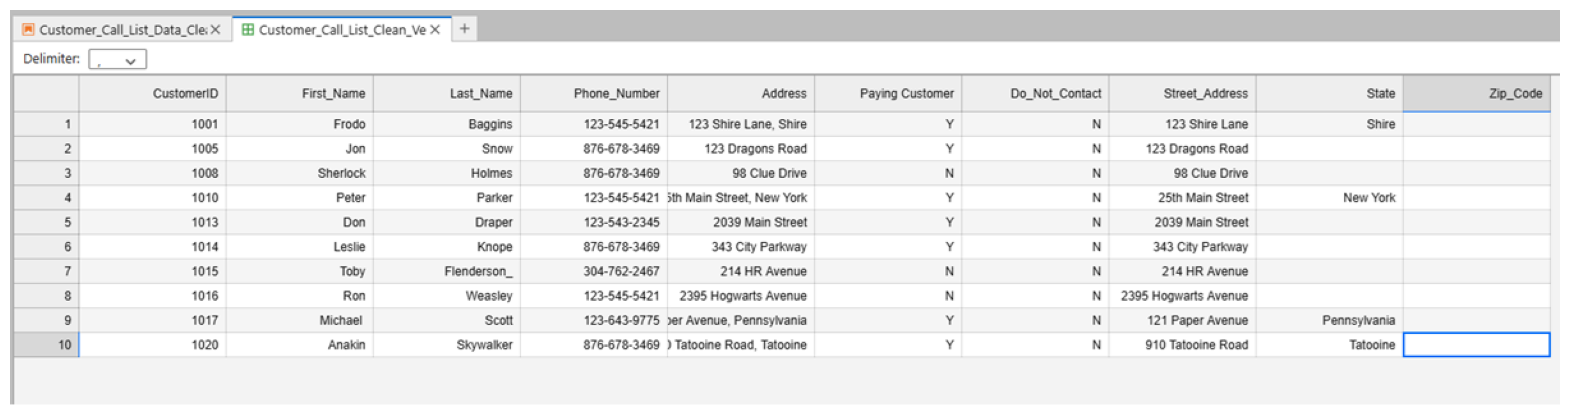

In [107]:
from PIL import Image                     # Import the Image class from the Python Imaging Library (PIL) to work with images
import matplotlib.pyplot as plt           # Import the matplotlib library's pyplot module for plotting and displaying images

img = Image.open(r"C:\Users\Mads\Desktop\Clean_Data_Screenshot.png")    
# Open the image file located at the given path and store it in the variable 'img'

plt.figure(figsize=(20, 10))              # Create a new figure with a specified size of 20 inches wide and 10 inches tall
plt.imshow(img)                           # Display the image stored in 'img' on the figure
plt.axis("off")                           # Hide the axis lines and labels for a cleaner display
plt.show()                                # Render and show the image in the output window



# Sample screenshot showing the final cleaned version of the file.